<a href="https://colab.research.google.com/github/Anushriya3007/ANUSHRIYA_4NI23CI018_ML2LAB_E1/blob/main/LAB_program_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
data = """Student_ID,Name,Age,Gender,Study_Hours,Attendance,Assignments,Exam_Score
1,Aarav,19,Male,5.5,92,8,85
2,Diya,20,Female,7.0,95,9,91
3,Rohan,18,Male,3.5,78,6,68
4,Ananya,19,Female,6.0,88,8,82
5,Vikram,21,Male,4.0,75,7,70
6,Meera,20,Female,8.0,98,10,96
7,Arjun,19,Male,,85,7,76
8,Sneha,18,Female,6.5,90,,88
9,Karan,22,Male,2.5,65,5,60
10,Ishita,20,Female,7.5,94,9,93
11,Rahul,21,Male,4.5,,6,72
12,Priya,19,Female,5.0,87,8,80
13,Aditya,20,Male,3.0,72,5,65
14,Nisha,18,Female,6.0,91,8,86
15,Manish,22,Male,4.0,80,7,74
16,Kavya,19,Female,8.5,99,10,98
17,Sameer,21,Male,5.5,89,8,81
18,Pooja,20,Female,7.0,93,9,90
19,Varun,18,Male,3.5,76,6,67
20,Neha,19,Female,6.5,88,8,84"""

with open("student_performance.csv", "w") as file:
    file.write(data)

df = pd.read_csv("student_performance.csv")

print(df.head())
print("Shape:", df.shape)
print(df)

   Student_ID    Name  Age  Gender  Study_Hours  Attendance  Assignments  \
0           1   Aarav   19    Male          5.5        92.0          8.0   
1           2    Diya   20  Female          7.0        95.0          9.0   
2           3   Rohan   18    Male          3.5        78.0          6.0   
3           4  Ananya   19  Female          6.0        88.0          8.0   
4           5  Vikram   21    Male          4.0        75.0          7.0   

   Exam_Score  
0          85  
1          91  
2          68  
3          82  
4          70  
Shape: (20, 8)
    Student_ID    Name  Age  Gender  Study_Hours  Attendance  Assignments  \
0            1   Aarav   19    Male          5.5        92.0          8.0   
1            2    Diya   20  Female          7.0        95.0          9.0   
2            3   Rohan   18    Male          3.5        78.0          6.0   
3            4  Ananya   19  Female          6.0        88.0          8.0   
4            5  Vikram   21    Male          4.

In [ ]:
print(df.head())
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# Fill numerical missing values with the mean
df["Study_Hours"] = df["Study_Hours"].fillna(df["Study_Hours"].mean())
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].mean())
df["Assignments"] = df["Assignments"].fillna(df["Assignments"].mean())

   Student_ID    Name  Age  Gender  Study_Hours  Attendance  Assignments  \
0           1   Aarav   19    Male          5.5        92.0          8.0   
1           2    Diya   20  Female          7.0        95.0          9.0   
2           3   Rohan   18    Male          3.5        78.0          6.0   
3           4  Ananya   19  Female          6.0        88.0          8.0   
4           5  Vikram   21    Male          4.0        75.0          7.0   

   Exam_Score  
0          85  
1          91  
2          68  
3          82  
4          70  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Student_ID   20 non-null     int64  
 1   Name         20 non-null     object 
 2   Age          20 non-null     int64  
 3   Gender       20 non-null     object 
 4   Study_Hours  19 non-null     float64
 5   Attendance   19 non-null     float64
 6   Assi

In [ ]:
df.fillna(df.mean(numeric_only=True),inplace=True)
print(df.isnull().sum())

Student_ID     0
Name           0
Age            0
Gender         0
Study_Hours    0
Attendance     0
Assignments    0
Exam_Score     0
dtype: int64


In [ ]:
# Pass = 1 if Exam Score >= 75
# Fail = 0 if Exam Score < 75

df["Result"] = (df["Exam_Score"] >= 75).astype(int)

print("\nDataset with Result:")
print(df[["Name", "Study_Hours", "Attendance",
          "Assignments", "Exam_Score", "Result"]])



Dataset with Result:
      Name  Study_Hours  Attendance  Assignments  Exam_Score  Result
0    Aarav     5.500000   92.000000     8.000000          85       1
1     Diya     7.000000   95.000000     9.000000          91       1
2    Rohan     3.500000   78.000000     6.000000          68       0
3   Ananya     6.000000   88.000000     8.000000          82       1
4   Vikram     4.000000   75.000000     7.000000          70       0
5    Meera     8.000000   98.000000    10.000000          96       1
6    Arjun     5.473684   85.000000     7.000000          76       1
7    Sneha     6.500000   90.000000     7.578947          88       1
8    Karan     2.500000   65.000000     5.000000          60       0
9   Ishita     7.500000   94.000000     9.000000          93       1
10   Rahul     4.500000   86.052632     6.000000          72       0
11   Priya     5.000000   87.000000     8.000000          80       1
12  Aditya     3.000000   72.000000     5.000000          65       0
13   Nisha  

In [ ]:

X = df[
    [
        "Age",
        "Gender",
        "Study_Hours",
        "Attendance",
        "Assignments"
    ]
]

y = df["Result"]

In [ ]:
X = pd.get_dummies(
    X,
    columns=["Gender"],
    drop_first=True
)


# Encode target
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("\nEncoded X:")
print(X)

print("\nEncoded y:")
print(y)


Encoded X:
    Age  Study_Hours  Attendance  Assignments  Gender_Male
0    19     5.500000   92.000000     8.000000         True
1    20     7.000000   95.000000     9.000000        False
2    18     3.500000   78.000000     6.000000         True
3    19     6.000000   88.000000     8.000000        False
4    21     4.000000   75.000000     7.000000         True
5    20     8.000000   98.000000    10.000000        False
6    19     5.473684   85.000000     7.000000         True
7    18     6.500000   90.000000     7.578947        False
8    22     2.500000   65.000000     5.000000         True
9    20     7.500000   94.000000     9.000000        False
10   21     4.500000   86.052632     6.000000         True
11   19     5.000000   87.000000     8.000000        False
12   20     3.000000   72.000000     5.000000         True
13   18     6.000000   91.000000     8.000000        False
14   22     4.000000   80.000000     7.000000         True
15   19     8.500000   99.000000    10.00000

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 16
Testing samples: 4


In [ ]:

model = DecisionTreeClassifier(
    random_state=42,
    max_depth=3
)


In [ ]:

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("\n========== MODEL EVALUATION ==========")
print(f"Accuracy  : {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1 Score  : {f1:.2f}")


========== MODEL EVALUATION ==========
Accuracy  : 0.75
Precision : 1.00
Recall    : 0.67
F1 Score  : 0.80


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[1 0]
 [1 2]]


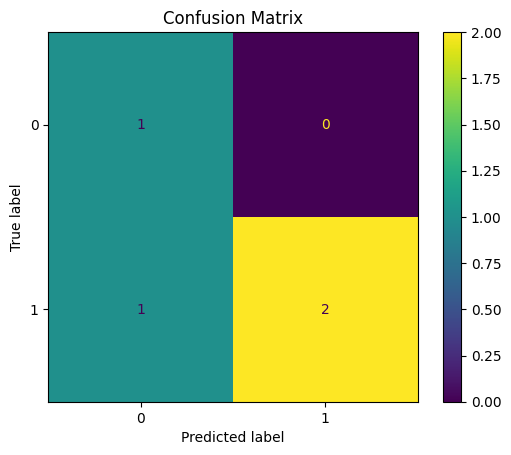

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

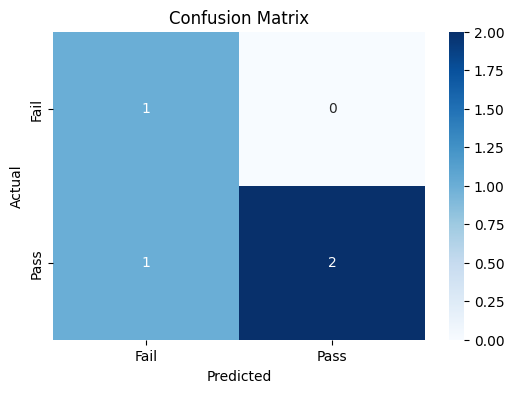

In [ ]:

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Fail", "Pass"],
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

        Fail       0.50      1.00      0.67         1
        Pass       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4

